### Reproduction fidèle de Martin-Abadal et al. (IEEE Access 2018)
### "Deep Semantic Segmentation in an AUV for Online Posidonia Oceanica Meadows Identification"

## Ce que reproduit ce notebook :
- Architecture VGG16-FCN8 (encodeur VGG16 ImageNet + décodeur FCN8)
- Resize EXACT à 480×360
- Loss = Cross-Entropy pure
- Optimiseur Adam, learning rate = 1e-05
- **16 000 itérations fixes - SANS early stopping** (ce que je faisais avant)
- Dropout 0.5 sur les deux couches fully-conv
- Data augmentation = UNIQUEMENT contraste + luminosité
- Initialisations décodeur : bilinear upsampling + gaussienne tronquée
- k-fold cross-validation (k=5) sur le dossier `training/` (= mix set)
- `testing/` utilisé comme extra set (évaluation externe uniquement)
- Métriques : Precision, Accuracy, Recall, Fall-out, ROC, AUC
- Seuil optimal via trade-off = (Recall + (1−Fallout)) / 2
- **10 runs × 5 folds = 50 modèles -> sélection du meilleur** (mais comme nous n'avons pas les ressources ceci est à revoir)

## Corrections apportées par rapport à v2 :
1. **Pas d'early stopping** : `train_one_fold` sauvegarde le modèle FINAL
   (à la dernière itération), pas le meilleur checkpoint sur val_loss.
2. **Sélection parmi 50 modèles** : `run_10_times_and_select_best()` relance
   10 fois le k-fold, calcule mean±std, sélectionne le meilleur modèle.
3. **Matching image/masque par stem** : gère les suffixes `_gt` dans gt_images/.
4. Structure des dossiers inchangée : `training/` et `testing/` tels que
   fournis par les encadrants.

#### 1. Importation des librairies

In [14]:
import os
import math
import random
import numpy as np
from pathlib import Path
import json


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights
import torchvision.transforms.functional as TF

from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve, auc

#### 2. Chemins et configuration globale

In [15]:
# ============================================================
# === CONFIGURATION — exécution Colab ou locale ===============
# ============================================================

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = "/content/drive/MyDrive/Stage_M2_GREAH/implémentation_détection_posidonie"
else:
    # >>> À ADAPTER selon ton PC <
    DRIVE_ROOT = r"D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie"

# --- Données (partagées entre architectures, comme pour SegFormer) ---
LOCAL_PATH = os.path.join(DRIVE_ROOT, "Dataset")
TRAIN_PATH = os.path.join(LOCAL_PATH, "training")  # mix set  (k-fold dessus)
TEST_PATH  = os.path.join(LOCAL_PATH, "testing")   # extra set (évaluation externe)

# --- Structure de sauvegarde, même schéma que SegFormer ---
# segformer  -> ARCH_DIR = DRIVE_ROOT/segformer/segformer_{variant}
# fcn_vgg16  -> ARCH_DIR = DRIVE_ROOT/fcn_vgg16
ARCH_DIR    = os.path.join(DRIVE_ROOT, "fcn_vgg16")
RESULTS_DIR = os.path.join(ARCH_DIR, "results")
KFOLD_DIR   = os.path.join(RESULTS_DIR, "kfold")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

# ============================================================
# === HYPERPARAMÈTRES (config gagnante de l'article) ==========
# ============================================================
N_CLASSES     = 2
IMG_H, IMG_W  = 360, 480
BATCH_SIZE    = 4
LEARNING_RATE = 1e-5
N_ITERATIONS  = 16000
N_RUNS        = 10
K_FOLDS       = 5
SEED          = 42

NUM_WORKERS = 0 if os.name == 'nt' else 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=== Configuration ===")
print(f"  Environnement   : {'Colab' if IN_COLAB else 'Local'}")
print(f"  DRIVE_ROOT      : {DRIVE_ROOT}")
print(f"  Dataset path    : {LOCAL_PATH}")
print(f"  ARCH_DIR        : {ARCH_DIR}")
print(f"  RESULTS_DIR     : {RESULTS_DIR}")
print(f"  KFOLD_DIR       : {KFOLD_DIR}")
print(f"  Image size      : {IMG_H} × {IMG_W}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Itérations      : {N_ITERATIONS}")
print(f"  K-Folds         : {K_FOLDS}  |  Runs : {N_RUNS}  -> {K_FOLDS*N_RUNS} modèles")
print(f"  Device          : {DEVICE}")

=== Configuration ===
  Environnement   : Local
  DRIVE_ROOT      : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie
  Dataset path    : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\Dataset
  ARCH_DIR        : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16
  RESULTS_DIR     : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16\results
  KFOLD_DIR       : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16\results\kfold
  Image size      : 360 × 480
  Batch size      : 4
  Learning rate   : 1e-05
  Itérations      : 16000
  K-Folds         : 5  |  Runs : 10  -> 50 modèles
  Device          : cpu


In [16]:
# ============================================================
# === SETUP DRIVE + ARBORESCENCE DE RÉSULTATS =================
# ============================================================

if IN_COLAB:
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount('/content/drive')
        print("Google Drive monté")
    else:
        print("Google Drive déjà monté")
else:
    print("Environnement local détecté (pas de Drive à monter)")

# Création de la structure de dossiers (no-op si déjà existant)
for d in [ARCH_DIR, RESULTS_DIR, KFOLD_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("\n=== Structure des dossiers ===")
print(f"  fcn_vgg16/        : {ARCH_DIR}")
print(f"  fcn_vgg16/results/: {RESULTS_DIR}")
print(f"    ├─ kfold/   : {KFOLD_DIR}")
print(f"    └─ figures/ : {FIGURES_DIR}")

# === Vérifications préalables (comme SegFormer) ===
print("\n=== Vérifications préalables ===")
for label, path in [("Training images", os.path.join(TRAIN_PATH, "images")),
                     ("Training gt_images", os.path.join(TRAIN_PATH, "gt_images")),
                     ("Testing images", os.path.join(TEST_PATH, "images")),
                     ("Testing gt_images", os.path.join(TEST_PATH, "gt_images"))]:
    if os.path.exists(path):
        n = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {label} : {n} fichiers ({path})")
    else:
        print(f"  {label} : INTROUVABLE ({path})")

if IN_COLAB:
    import shutil as sh
    stat = sh.disk_usage('/content')
    print(f"\nEspace disque Colab : {stat.free/1e9:.1f} GB libres / {stat.total/1e9:.1f} GB")

Environnement local détecté (pas de Drive à monter)

=== Structure des dossiers ===
  fcn_vgg16/        : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16
  fcn_vgg16/results/: D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16\results
    ├─ kfold/   : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16\results\kfold
    └─ figures/ : D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\fcn_vgg16\results\figures

=== Vérifications préalables ===
  Training images : 376 fichiers (D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\Dataset\training\images)
  Training gt_images : 376 fichiers (D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\Dataset\training\gt_images)
  Testing images : 94 fichiers (D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\Dataset\testing\images)
  Testing gt_images : 94 fichiers (D:\Corine\STAGE_M2_GREAH\implémentation_détection_posidonie\Dataset\testing\gt_images)


#### 3. Architecture VGG16-FCN8 (identique à v2, inchangée)

In [17]:
class FCN8VGG16(nn.Module):
    """
    Encodeur : VGG16 jusqu'à pool5, puis conv6 (7×7) et conv7 (1×1)
               converties depuis FC, avec dropout 0.5 — article II-A.
    Décodeur : skip connections depuis pool3 et pool4 (FCN-8).
               F.interpolate(..., size=skip.shape) = transposed conv bilinéaire,
               gère proprement les dimensions non-multiples de 32.
    """
    def __init__(self, num_classes=2, pretrained=True, dropout=0.5):
        super().__init__()
        weights = VGG16_Weights.IMAGENET1K_V1 if pretrained else None
        vgg      = vgg16(weights=weights)
        features = list(vgg.features.children())

        self.pool3 = nn.Sequential(*features[:17])    # H/8,  256 ch
        self.pool4 = nn.Sequential(*features[17:24])  # H/16, 512 ch
        self.pool5 = nn.Sequential(*features[24:31])  # H/32, 512 ch

        self.conv6 = nn.Conv2d(512,  4096, kernel_size=7, padding=3)
        self.relu6 = nn.ReLU(inplace=True)
        self.drop6 = nn.Dropout2d(p=dropout)   # dropout 0.5 (article)

        self.conv7 = nn.Conv2d(4096, 4096, kernel_size=1)
        self.relu7 = nn.ReLU(inplace=True)
        self.drop7 = nn.Dropout2d(p=dropout)   # dropout 0.5 (article)

        self.score_fr    = nn.Conv2d(4096, num_classes, kernel_size=1)
        self.score_pool4 = nn.Conv2d(512,  num_classes, kernel_size=1)
        self.score_pool3 = nn.Conv2d(256,  num_classes, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        # Skip connections : gaussienne tronquée à faible std (article II-B)
        for m in [self.score_fr, self.score_pool4, self.score_pool3]:
            nn.init.normal_(m.weight, mean=0.0, std=0.01)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
        # Conv6/7 : Kaiming
        for m in [self.conv6, self.conv7]:
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):
        in_size = x.shape[2:]
        p3 = self.pool3(x)
        p4 = self.pool4(p3)
        p5 = self.pool5(p4)

        x     = self.drop6(self.relu6(self.conv6(p5)))
        x     = self.drop7(self.relu7(self.conv7(x)))
        score = self.score_fr(x)

        u2    = F.interpolate(score, size=p4.shape[2:], mode='bilinear', align_corners=False)
        fuse4 = u2 + self.score_pool4(p4)

        u4    = F.interpolate(fuse4, size=p3.shape[2:], mode='bilinear', align_corners=False)
        fuse3 = u4 + self.score_pool3(p3)

        return F.interpolate(fuse3, size=in_size, mode='bilinear', align_corners=False)

#### 4. Dataset — gestion du suffixe `_gt` dans gt_images/

**Correction v3** : le matching image/masque se fait par **stem** (nom sans extension),
avec fallback sur `stem + '_gt'`. Cela gère les conventions :
- `image001.png` ↔ `image001_gt.png`  (ton dataset)
- `image001.png` ↔ `image001.png`     (convention générique)

La logique `split='training'`/`'testing'` est conservée pour rester
compatible avec ta structure de dossiers.

In [18]:
class PosidoniaDataset(Dataset):
    """
    Lit les couples (image, masque) depuis root_path/split/.
    Structure attendue :
      root_path/split/images/     — images RGB
      root_path/split/gt_images/  — masques ground truth
        Masques training : RGB, rouge = posidonie (R>150, G<120, B<120)
        Masques testing  : niveaux de gris, blanc (>128) = posidonie
        Les masques peuvent avoir le suffixe _gt (ex. img001_gt.png).

    augment=True applique UNIQUEMENT contraste + luminosité (article II-B).
    """
    VALID_EXT = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

    def __init__(self, root_path, split='training', augment=False):
        self.split   = split
        self.augment = augment

        img_dir  = os.path.join(root_path, split, 'images')
        mask_dir = os.path.join(root_path, split, 'gt_images')

        # --- Chargement des images ---
        imgs = sorted([f for f in os.listdir(img_dir)
                       if f.lower().endswith(self.VALID_EXT)])

        # --- Matching image → masque par stem (gère le suffixe _gt) ---
        # Construit un index : stem_masque -> chemin_masque
        mask_index = {}
        for f in os.listdir(mask_dir):
            if f.lower().endswith(self.VALID_EXT):
                stem = Path(f).stem          # ex. 'img001_gt' ou 'img001'
                mask_index[stem] = os.path.join(mask_dir, f)

        self.images, self.masks = [], []
        missing = []
        for f in imgs:
            stem_img = Path(f).stem          # ex. 'img001'
            # Cherche d'abord 'img001_gt', puis 'img001'
            if stem_img + '_gt' in mask_index:
                mask_path = mask_index[stem_img + '_gt']
            elif stem_img in mask_index:
                mask_path = mask_index[stem_img]
            else:
                missing.append(f)
                continue
            self.images.append(os.path.join(img_dir, f))
            self.masks.append(mask_path)

        if missing:
            print(f'[WARN] {len(missing)} image(s) sans masque ignorée(s) : {missing[:5]}')
        print(f'Dataset [{split}] : {len(self.images)} paires image/masque chargées')

        self.resize_img  = transforms.Resize((IMG_H, IMG_W))
        self.resize_mask = transforms.Resize(
            (IMG_H, IMG_W), interpolation=transforms.InterpolationMode.NEAREST)
        self.to_tensor   = transforms.ToTensor()

    def _mask_to_class(self, mask_pil):
        """Convertit le masque PIL en carte de classes int64 (0=fond, 1=posidonie)."""
        if self.split == 'testing':
            # Niveaux de gris : blanc (>128) = posidonie
            arr = np.array(mask_pil.convert('L'))
            return (arr > 128).astype(np.int64)
        # training : RGB — rouge = posidonie (R>150, G<120, B<120)
        arr = np.array(mask_pil.convert('RGB'))
        r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
        return ((r > 150) & (g < 120) & (b < 120)).astype(np.int64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = Image.open(self.images[idx]).convert('RGB')
        mask = Image.open(self.masks[idx])

        img  = self.resize_img(img)
        mask = self.resize_mask(mask)

        # Augmentation UNIQUEMENT contraste + luminosité (article II-B)
        # Le masque n'est PAS modifié (transformation photométrique)
        if self.augment and self.split == 'training':
            img = transforms.ColorJitter(brightness=0.3, contrast=0.3)(img)

        mask_np     = self._mask_to_class(mask)
        img_tensor  = self.to_tensor(img)
        mask_tensor = torch.from_numpy(mask_np).long()
        return img_tensor, mask_tensor

#### 5. Calcul des métriques durant l'entraînement

In [19]:
def compute_metrics_from_logits(logits, masks, eps=1e-7):
    """
    Calcule TP/FP/TN/FN + Accuracy/Precision/Recall/Fall-out
    à partir des logits bruts (argmax comme seuil implicite 0.5).
    logits : [B, 2, H, W] — masks : [B, H, W]
    """
    preds = torch.argmax(logits, dim=1)
    TP = ((preds == 1) & (masks == 1)).sum().item()
    FP = ((preds == 1) & (masks == 0)).sum().item()
    TN = ((preds == 0) & (masks == 0)).sum().item()
    FN = ((preds == 0) & (masks == 1)).sum().item()
    tot = TP + TN + FP + FN + eps
    return {
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
        'accuracy':  (TP + TN) / tot,
        'precision': TP / (TP + FP + eps),
        'recall':    TP / (TP + FN + eps),
        'fallout':   FP / (FP + TN + eps),
    }

#### 6. Entraînement — N itérations fixes, SANS early stopping

**Correction clé vs v2** : dans v2, `torch.save` était appelé à chaque fois
que `val_loss` s'améliorait → **early stopping déguisé**.

Martin entraîne exactement 16 000 itérations et sauvegarde le modèle **final**.
Ici, `torch.save` est appelé **une seule fois**, après la boucle.

Le log des métriques (history) sert uniquement à tracer les courbes
d'apprentissage — il n'influence plus quel modèle est sauvegardé.

In [20]:
def train_one_fold(train_subset, val_subset, n_iter=N_ITERATIONS,
                   lr=LEARNING_RATE, model_path='fcn8_fold.pth',
                   val_every=500, verbose=True,
                   resume_path=None, resume_every=500,
                   best_val_path=None):
    """
    Entraîne exactement n_iter itérations (procédure de Martin-Abadal).

    Trois fichiers de sortie, à ne pas confondre :

    - model_path     : MODELE FINAL — poids après exactement n_iter
                        itérations. C'est CELUI utilisé pour evaluate_full()
                        et la sélection parmi les 50 modèles. Sauvegardé
                        UNE SEULE FOIS, à la fin.

    - resume_path    : checkpoint de REPRISE (poids + optimiseur +
                        iter_count + history). Sauvegardé à chaque
                        `resume_every` itérations, TOUJOURS avec l'état
                        le plus récent (peu importe val_loss). Sert
                        uniquement à survivre à un crash. Supprimé en
                        fin de fold.

    - best_val_path  : checkpoint INFORMATIF — poids du modèle au moment
                        où val_loss était la plus basse observée. Sauvegardé
                        UNIQUEMENT si val_loss s'améliore. N'est JAMAIS
                        utilisé pour evaluate_full() ni pour la sélection
                        finale — sert uniquement à comparer a posteriori
                        "meilleur point intermédiaire" vs "modèle final"
                        (discussion sur-apprentissage dans le mémoire).
                        Si None, ce checkpoint n'est pas créé.
    """
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
    val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

    model     = FCN8VGG16(num_classes=N_CLASSES, pretrained=True).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'iter': [], 'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': [], 'train_prec': [], 'val_prec': [],
               'train_rec': [], 'val_rec': [], 'train_fall': [], 'val_fall': []}

    iter_count = 0
    train_loss_sum = 0.0
    train_TP = train_FP = train_TN = train_FN = train_n = 0
    best_val_loss = float('inf')  # uniquement pour best_val_path (informatif)

    # --- REPRISE depuis un checkpoint existant ---
    if resume_path and os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        iter_count = ckpt['iter_count']
        history = ckpt['history']
        best_val_loss = ckpt.get('best_val_loss', float('inf'))
        print(f"[REPRISE] {resume_path} -> reprise à l'itération {iter_count}/{n_iter}")

    pbar = tqdm(total=n_iter, initial=iter_count, desc='Iterations', disable=not verbose)
    train_iter = iter(train_loader)
    model.train()

    while iter_count < n_iter:
        try:
            imgs, masks = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            imgs, masks = next(train_iter)

        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            m = compute_metrics_from_logits(logits.detach(), masks)
            train_TP += m['TP']; train_FP += m['FP']
            train_TN += m['TN']; train_FN += m['FN']
            train_loss_sum += loss.item()
            train_n += 1

        iter_count += 1
        pbar.update(1)

        if iter_count % val_every == 0 or iter_count == n_iter:
            eps = 1e-7
            t = train_TP + train_TN + train_FP + train_FN + eps
            tr = {
                'loss': train_loss_sum / max(train_n, 1),
                'acc':  (train_TP + train_TN) / t,
                'prec': train_TP / (train_TP + train_FP + eps),
                'rec':  train_TP / (train_TP + train_FN + eps),
                'fall': train_FP / (train_FP + train_TN + eps),
            }

            model.eval()
            vl_sum = 0.0
            vTP = vFP = vTN = vFN = 0
            with torch.no_grad():
                for vi, vm in val_loader:
                    vi, vm = vi.to(DEVICE), vm.to(DEVICE)
                    vlogits = model(vi)
                    vl_sum += criterion(vlogits, vm).item()
                    vm_ = compute_metrics_from_logits(vlogits, vm)
                    vTP += vm_['TP']; vFP += vm_['FP']
                    vTN += vm_['TN']; vFN += vm_['FN']

            vt = vTP + vTN + vFP + vFN + eps
            va = {
                'loss': vl_sum / len(val_loader),
                'acc':  (vTP + vTN) / vt,
                'prec': vTP / (vTP + vFP + eps),
                'rec':  vTP / (vTP + vFN + eps),
                'fall': vFP / (vFP + vTN + eps),
            }

            history['iter'].append(iter_count)
            for k_ in ['loss', 'acc', 'prec', 'rec', 'fall']:
                history[f'train_{k_}'].append(tr[k_])
                history[f'val_{k_}'].append(va[k_])

            # --- Checkpoint INFORMATIF (best val_loss) ---
            # N'influence ni la boucle, ni model_path, ni l'évaluation finale.
            star = ""
            if best_val_path and va['loss'] < best_val_loss:
                best_val_loss = va['loss']
                torch.save({
                    'model_state': model.state_dict(),
                    'iter_count': iter_count,
                    'val_loss': va['loss'],
                }, best_val_path)
                star = " *"  # marqueur visuel dans les logs

            if verbose:
                tqdm.write(
                    f'[iter {iter_count:6d}] '
                    f'loss tr={tr["loss"]:.4f} val={va["loss"]:.4f}{star}  |  '
                    f'acc tr={tr["acc"]:.3f} val={va["acc"]:.3f}  |  '
                    f'prec tr={tr["prec"]:.3f} val={va["prec"]:.3f}  |  '
                    f'rec tr={tr["rec"]:.3f} val={va["rec"]:.3f}  |  '
                    f'fall tr={tr["fall"]:.3f} val={va["fall"]:.3f}'
                )

            train_loss_sum = 0.0
            train_TP = train_FP = train_TN = train_FN = train_n = 0
            model.train()

        # --- Checkpoint de REPRISE (toujours l'état le plus récent) ---
        if resume_path and (iter_count % resume_every == 0 or iter_count == n_iter):
            torch.save({
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'iter_count': iter_count,
                'history': history,
                'best_val_loss': best_val_loss,
            }, resume_path)

    pbar.close()

    # --- MODELE FINAL (poids seuls) — celui utilisé pour l'évaluation ---
    torch.save(model.state_dict(), model_path)

    # Nettoyage du checkpoint de reprise une fois le fold terminé
    if resume_path and os.path.exists(resume_path):
        os.remove(resume_path)

    if best_val_path:
        print(f"  [info] Meilleur val_loss observé : {best_val_loss:.4f} "
              f"(sauvegardé dans {best_val_path}, à titre informatif uniquement)")

    return model_path, history

#### 7. Évaluation : Precision / Accuracy / Recall / Fall-out / ROC / AUC

In [21]:
@torch.no_grad()
def get_predictions(model, dataset):
    """Retourne (probas posidonie, labels vrais) aplatis sur tous les pixels."""
    model.eval()
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    probs_all, labels_all = [], []
    for imgs, masks in loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)[:, 1]  # proba classe posidonie
        probs_all.append(probs.cpu().numpy())
        labels_all.append(masks.numpy())
    probs_all  = np.concatenate([p.ravel() for p in probs_all])
    labels_all = np.concatenate([m.ravel() for m in labels_all])
    return probs_all, labels_all


def metrics_at_threshold(probs, labels, threshold):
    pred = (probs >= threshold).astype(np.uint8)
    TP = np.sum((pred == 1) & (labels == 1))
    FP = np.sum((pred == 1) & (labels == 0))
    TN = np.sum((pred == 0) & (labels == 0))
    FN = np.sum((pred == 0) & (labels == 1))
    eps = 1e-7
    return dict(
        accuracy  = (TP + TN) / (TP + TN + FP + FN + eps),
        precision = TP / (TP + FP + eps),
        recall    = TP / (TP + FN + eps),
        fallout   = FP / (FP + TN + eps),
        TP=TP, FP=FP, TN=TN, FN=FN,
    )


def evaluate_full(model, dataset, n_thresholds=9):
    """
    Reproduit la procédure de l'article (section III-C.2) :
    - 9 seuils équidistants (0.1 à 0.9)
    - seuil optimal = meilleur trade-off = (Recall + (1−Fallout)) / 2
    - ROC + AUC calculés sur la sortie probabiliste continue
    """
    probs, labels = get_predictions(model, dataset)
    thresholds    = np.linspace(0.1, 0.9, n_thresholds)
    results = []
    for t in thresholds:
        m = metrics_at_threshold(probs, labels, t)
        m['threshold'] = float(t)
        m['tradeoff']  = (m['recall'] + (1 - m['fallout'])) / 2
        results.append(m)
    best = max(results, key=lambda d: d['tradeoff'])
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc     = auc(fpr, tpr)
    return {
        'per_threshold': results,
        'best':   best,
        'roc':    (fpr, tpr, roc_auc),
        'probs':  probs,
        'labels': labels,
    }

#### 8. K-fold cross-validation (k=5) sur `training/`

Le dossier `training/` contient toutes les images du mix set.
Le `KFold` décide quelles images vont en train/val à chaque fold.
Partition aléatoire simple (pas de stratification — fidèle à Martin).

In [22]:
def _to_serializable(obj):
    """Convertit récursivement numpy/torch en types JSON-sérialisables."""
    if isinstance(obj, dict):
        return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def kfold_experiment(n_iter=N_ITERATIONS, lr=LEARNING_RATE,
                     augment=True, k=K_FOLDS, tag='exp', run_id=0):
    """
    Lance k folds sur training/ (mix set) et évalue aussi sur testing/ (extra set).
    Sauvegarde, pour chaque fold, dans KFOLD_DIR :
      - {name}.pth          : modèle final (16000 iter) — utilisé pour evaluate_full
      - {name}_bestval.pth  : meilleur checkpoint selon val_loss (informatif)
      - {name}_metadata.json: métriques mix + extra, seuils optimaux, AUC, history
    Le checkpoint de reprise {name}_resume.pth est créé pendant l'entraînement
    puis supprimé en fin de fold.
    """
    run_seed = SEED + run_id

    train_ds_aug   = PosidoniaDataset(LOCAL_PATH, split='training', augment=augment)
    train_ds_noaug = PosidoniaDataset(LOCAL_PATH, split='training', augment=False)
    extra_ds       = PosidoniaDataset(LOCAL_PATH, split='testing',  augment=False)

    indices = np.arange(len(train_ds_aug))
    kf = KFold(n_splits=k, shuffle=True, random_state=run_seed)

    fold_results_mix   = []
    fold_results_extra = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
        print(f'\n========== Run {run_id+1} | Fold {fold+1}/{k} ==========')

        train_subset = Subset(train_ds_aug,   train_idx.tolist())
        val_subset   = Subset(train_ds_noaug, val_idx.tolist())

        name = f'fcn8_{tag}_run{run_id:02d}_fold{fold+1}'

        # --- Tous les chemins de checkpoints sont maintenant dans KFOLD_DIR ---
        ckpt_path     = os.path.join(KFOLD_DIR, f'{name}.pth')          # modèle final officiel
        resume_path   = os.path.join(KFOLD_DIR, f'{name}_resume.pth')   # reprise après crash
        best_val_path = os.path.join(KFOLD_DIR, f'{name}_bestval.pth')  # informatif
        meta_path     = os.path.join(KFOLD_DIR, f'{name}_metadata.json')

        # --- Reprise possible si entraînement déjà terminé pour ce fold ---
        if os.path.exists(ckpt_path) and os.path.exists(meta_path):
            print(f'  [SKIP] {name} déjà entraîné -> rechargement des résultats existants')
            with open(meta_path, 'r') as f:
                meta = json.load(f)
            model = FCN8VGG16(num_classes=N_CLASSES, pretrained=False).to(DEVICE)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
            res_mix   = evaluate_full(model, val_subset)
            res_extra = evaluate_full(model, extra_ds)
            fold_results_mix.append({'ckpt': ckpt_path, 'best_val_ckpt': best_val_path, **res_mix})
            fold_results_extra.append(res_extra)
            continue

        _, history = train_one_fold(
            train_subset, val_subset,
            n_iter=n_iter, lr=lr,
            model_path=ckpt_path,
            resume_path=resume_path,
            best_val_path=best_val_path,
            val_every=500,
            verbose=True
        )

        # Chargement du modèle FINAL (celui utilisé pour l'évaluation)
        model = FCN8VGG16(num_classes=N_CLASSES, pretrained=False).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

        res_mix   = evaluate_full(model, val_subset)
        res_extra = evaluate_full(model, extra_ds)

        fold_results_mix.append({'ckpt': ckpt_path, 'best_val_ckpt': best_val_path,
                                  'history': history, **res_mix})
        fold_results_extra.append(res_extra)

        print(f'  [mix]   acc={res_mix["best"]["accuracy"]:.4f}  '
              f'prec={res_mix["best"]["precision"]:.4f}  '
              f'rec={res_mix["best"]["recall"]:.4f}  '
              f'fall={res_mix["best"]["fallout"]:.4f}  '
              f'AUC={res_mix["roc"][2]:.4f}')
        print(f'  [extra] acc={res_extra["best"]["accuracy"]:.4f}  '
              f'prec={res_extra["best"]["precision"]:.4f}  '
              f'AUC={res_extra["roc"][2]:.4f}')

        # --- Sauvegarde des métadonnées du fold (JSON, comme SegFormer) ---
        metadata = {
            'name': name,
            'tag': tag,
            'run_id': run_id,
            'fold': fold,
            'n_iter': n_iter,
            'lr': lr,
            'augment': augment,
            'n_train': len(train_idx),
            'n_val': len(val_idx),
            'n_extra': len(extra_ds),
            'ckpt_path': ckpt_path,
            'best_val_path': best_val_path,
            'mix_metrics': res_mix['best'],
            'mix_auc': float(res_mix['roc'][2]),
            'extra_metrics': res_extra['best'],
            'extra_auc': float(res_extra['roc'][2]),
            'history_last': {k_: v[-1] for k_, v in history.items() if k_ != 'iter' and len(v) > 0},
        }
        with open(meta_path, 'w') as f:
            json.dump(_to_serializable(metadata), f, indent=2)
        print(f'  [meta] {meta_path}')

    return fold_results_mix, fold_results_extra

def aggregate(folds):
    """Calcule moyenne et écart-type des métriques 'best' sur k folds."""
    summary = {}
    for key in ['accuracy', 'precision', 'recall', 'fallout']:
        vals = [f['best'][key] for f in folds]
        summary[key] = (float(np.mean(vals)), float(np.std(vals)))
    aucs = [f['roc'][2] for f in folds]
    summary['AUC'] = (float(np.mean(aucs)), float(np.std(aucs)))
    return summary

#### 9. Étude de cas — 8 configurations de la Table 2

In [23]:
def run_paper_study_cases():
    """
    Reproduit les 8 configurations de la Table 2 (section III-B).
    Chaque configuration = 1 run k-fold (5 modèles).
    La sélection des 50 modèles (section IV-B.2) est faite séparément
    sur la config gagnante (1_1_16) via run_10_times_and_select_best().
    """
    cases = [
        # (tag,      augment,  lr,    iters)
        ('0_1_8',   False,    1e-5,   8000),
        ('0_1_16',  False,    1e-5,  16000),
        ('0_5_8',   False,    5e-4,   8000),
        ('0_5_16',  False,    5e-4,  16000),
        ('1_1_8',   True,     1e-5,   8000),
        ('1_1_16',  True,     1e-5,  16000),   # config gagnante
        ('1_5_8',   True,     5e-4,   8000),
        ('1_5_16',  True,     5e-4,  16000),
    ]

    all_results = {}
    for tag, aug, lr, n_it in cases:
        print(f'\n############ Cas {tag} '
              f'(aug={int(aug)}, lr={lr}, iter={n_it}) ############')
        folds_mix, folds_extra = kfold_experiment(
            n_iter=n_it, lr=lr, augment=aug, tag=tag, run_id=0
        )
        s = aggregate(folds_mix)
        print(f'  >>> {tag} (mix) : '
              f'prec={s["precision"][0]:.4f}±{s["precision"][1]:.4f}  '
              f'acc={s["accuracy"][0]:.4f}±{s["accuracy"][1]:.4f}  '
              f'AUC={s["AUC"][0]:.4f}')
        all_results[tag] = {'mix_folds': folds_mix, 'extra_folds': folds_extra}

    return all_results

#### 10. Sélection du meilleur modèle parmi 50 (section IV-B.2)

Martin : *"We make an in-depth study of the performance variability by
re-conducting ten times the validation process, obtaining a total of
fifty output models. After evaluating all models, we carry out a
statistical analysis [...] and select the model with best performance."*

Résultats de l'article :
- Precision : 96.95% ± 0.97%
- Accuracy  : 96.08% ± 0.49%
- Meilleur modèle final : precision=96.57%, accuracy=96.81%

In [24]:
def run_10_times_and_select_best(tag='1_1_16'):
    """
    Lance 10 fois le k-fold complet sur la config gagnante (1_1_16).
    -> 10 runs x 5 folds = 50 modèles FINAUX (pas de early stopping).
    Calcule mean±std, sélectionne le meilleur par score=(prec+acc)/2.
    """
    all_fold_results = []

    for run_id in range(N_RUNS):
        print(f'\n########## RUN {run_id+1}/{N_RUNS} ##########')
        folds_mix, _ = kfold_experiment(
            n_iter=N_ITERATIONS, lr=LEARNING_RATE,
            augment=True, tag=tag, run_id=run_id
        )
        all_fold_results.extend(folds_mix)

    # ---- Statistiques sur les 50 modèles ----
    precisions = [r['best']['precision'] for r in all_fold_results]
    accuracies = [r['best']['accuracy']  for r in all_fold_results]
    print(f'\n=== Résultats sur {len(all_fold_results)} modèles ===')
    print(f'Precision : {np.mean(precisions)*100:.2f}% ± {np.std(precisions)*100:.2f}%')
    print(f'Accuracy  : {np.mean(accuracies)*100:.2f}% ± {np.std(accuracies)*100:.2f}%')
    print(f'  (Article : Precision 96.95%±0.97%, Accuracy 96.08%±0.49%)')

    # ---- Sélection du meilleur parmi 50 ----
    scores   = [(p + a) / 2 for p, a in zip(precisions, accuracies)]
    best_idx  = int(np.argmax(scores))
    best_ckpt = all_fold_results[best_idx]['ckpt']
    print(f'\n=== Meilleur modèle sélectionné : {best_ckpt} ===')
    print(f'  precision={precisions[best_idx]*100:.2f}%  '
          f'accuracy={accuracies[best_idx]*100:.2f}%')
    print(f'  (Article : precision=96.57%, accuracy=96.81%)')

    return best_ckpt, all_fold_results

#### 11. Visualisations (ROC, courbes d'apprentissage, segmentation)

In [25]:
def plot_roc(results_dict, savepath='roc_comparison.png'):
    """Reproduit la Figure 7(a) de l'article."""
    plt.figure(figsize=(7, 6))
    for tag, res in results_dict.items():
        probs = np.concatenate([f['probs']  for f in res['mix_folds']])
        labs  = np.concatenate([f['labels'] for f in res['mix_folds']])
        fpr, tpr, _ = roc_curve(labs, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{tag}  AUC={roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('Fall-out (FPR)'); plt.ylabel('Recall (TPR)')
    plt.title('Courbes ROC — comparaison des configurations (Figure 7a)')
    plt.legend(loc='lower right'); plt.grid(True)
    plt.tight_layout(); plt.savefig(savepath); plt.show()


def plot_history(history, savepath='training_curves.png'):
    """Courbes d'apprentissage (loss, accuracy, precision/recall, fall-out)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    it = history['iter']
    axes[0,0].plot(it, history['train_loss'], label='train')
    axes[0,0].plot(it, history['val_loss'],   label='val')
    axes[0,0].set_title('Cross-Entropy Loss'); axes[0,0].legend()
    axes[0,0].set_xlabel('itération'); axes[0,0].grid(True)
    axes[0,1].plot(it, history['train_acc'], label='train')
    axes[0,1].plot(it, history['val_acc'],   label='val')
    axes[0,1].set_title('Accuracy'); axes[0,1].legend()
    axes[0,1].set_xlabel('itération'); axes[0,1].grid(True)
    axes[1,0].plot(it, history['train_prec'], label='train prec')
    axes[1,0].plot(it, history['val_prec'],   label='val prec')
    axes[1,0].plot(it, history['train_rec'],  '--', label='train rec')
    axes[1,0].plot(it, history['val_rec'],    '--', label='val rec')
    axes[1,0].set_title('Precision (pleins) / Recall (tirets)')
    axes[1,0].legend(); axes[1,0].set_xlabel('itération'); axes[1,0].grid(True)
    axes[1,1].plot(it, history['train_fall'], label='train')
    axes[1,1].plot(it, history['val_fall'],   label='val')
    axes[1,1].set_title('Fall-out (FPR)'); axes[1,1].legend()
    axes[1,1].set_xlabel('itération'); axes[1,1].grid(True)
    plt.tight_layout(); plt.savefig(savepath); plt.show()


@torch.no_grad()
def show_qualitative(model, dataset, threshold=0.5, n=4):
    """Reproduit la Figure 8 : superposition verte de la prédiction."""
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    for i in range(n):
        img_t, mask_t = dataset[i]
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        prob   = F.softmax(logits, dim=1)[0, 1].cpu().numpy()
        pred   = (prob >= threshold).astype(np.uint8)
        img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        overlay = img_np.copy()
        overlay[pred == 1, 1] = 255
        blended = (img_np * 0.55 + overlay * 0.45).astype(np.uint8)
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title('Image originale'); axes[i, 0].axis('off')
        axes[i, 1].imshow(blended)
        axes[i, 1].set_title('Segmentation (vert = posidonie)')
        axes[i, 1].axis('off')
    plt.tight_layout(); plt.show()

#### 12. Chargement des données et test rapide du pipeline

Ce bloc valide que le dataset charge correctement (matching image/masque,
suffixes `_gt`, dimensions) puis lance 200 itérations sur un seul fold.

In [26]:
# Vérification du chargement des données
train_ds = PosidoniaDataset(LOCAL_PATH, split='training', augment=True)
extra_ds = PosidoniaDataset(LOCAL_PATH, split='testing',  augment=False)
print(f'Mix set   : {len(train_ds)} images')
print(f'Extra set : {len(extra_ds)} images')

# Vérification d'un exemple
img_t, mask_t = train_ds[0]
print(f'Image tensor : {img_t.shape}  (attendu : [3, 360, 480])')
print(f'Masque tensor: {mask_t.shape}  (attendu : [360, 480])')
print(f'Classes présentes : {mask_t.unique().tolist()}  (attendu : [0, 1])')

Dataset [training] : 376 paires image/masque chargées
Dataset [testing] : 94 paires image/masque chargées
Mix set   : 376 images
Extra set : 94 images
Image tensor : torch.Size([3, 360, 480])  (attendu : [3, 360, 480])
Masque tensor: torch.Size([360, 480])  (attendu : [360, 480])
Classes présentes : [0, 1]  (attendu : [0, 1])


Dataset [training] : 376 paires image/masque chargées
Dataset [training] : 376 paires image/masque chargées


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\trant/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:07<00:00, 72.7MB/s] 
Iterations:  25%|██▌       | 50/200 [13:28<36:52, 14.75s/it]

[iter     50] loss tr=0.4496 val=0.3195  |  acc tr=0.796 val=0.859  |  prec tr=0.785 val=0.920  |  rec tr=0.735 val=0.750  |  fall tr=0.156 val=0.052


Iterations:  50%|█████     | 100/200 [27:09<24:18, 14.58s/it] 

[iter    100] loss tr=0.2714 val=0.2100  |  acc tr=0.891 val=0.917  |  prec tr=0.882 val=0.890  |  rec tr=0.869 val=0.928  |  fall tr=0.092 val=0.092


Iterations:  75%|███████▌  | 150/200 [40:46<12:17, 14.75s/it]  

[iter    150] loss tr=0.2208 val=0.1962  |  acc tr=0.915 val=0.923  |  prec tr=0.901 val=0.887  |  rec tr=0.896 val=0.948  |  fall tr=0.071 val=0.098


Iterations: 100%|██████████| 200/200 [54:18<00:00, 16.29s/it]


[iter    200] loss tr=0.1968 val=0.1674  |  acc tr=0.922 val=0.933  |  prec tr=0.910 val=0.917  |  rec tr=0.909 val=0.934  |  fall tr=0.069 val=0.068


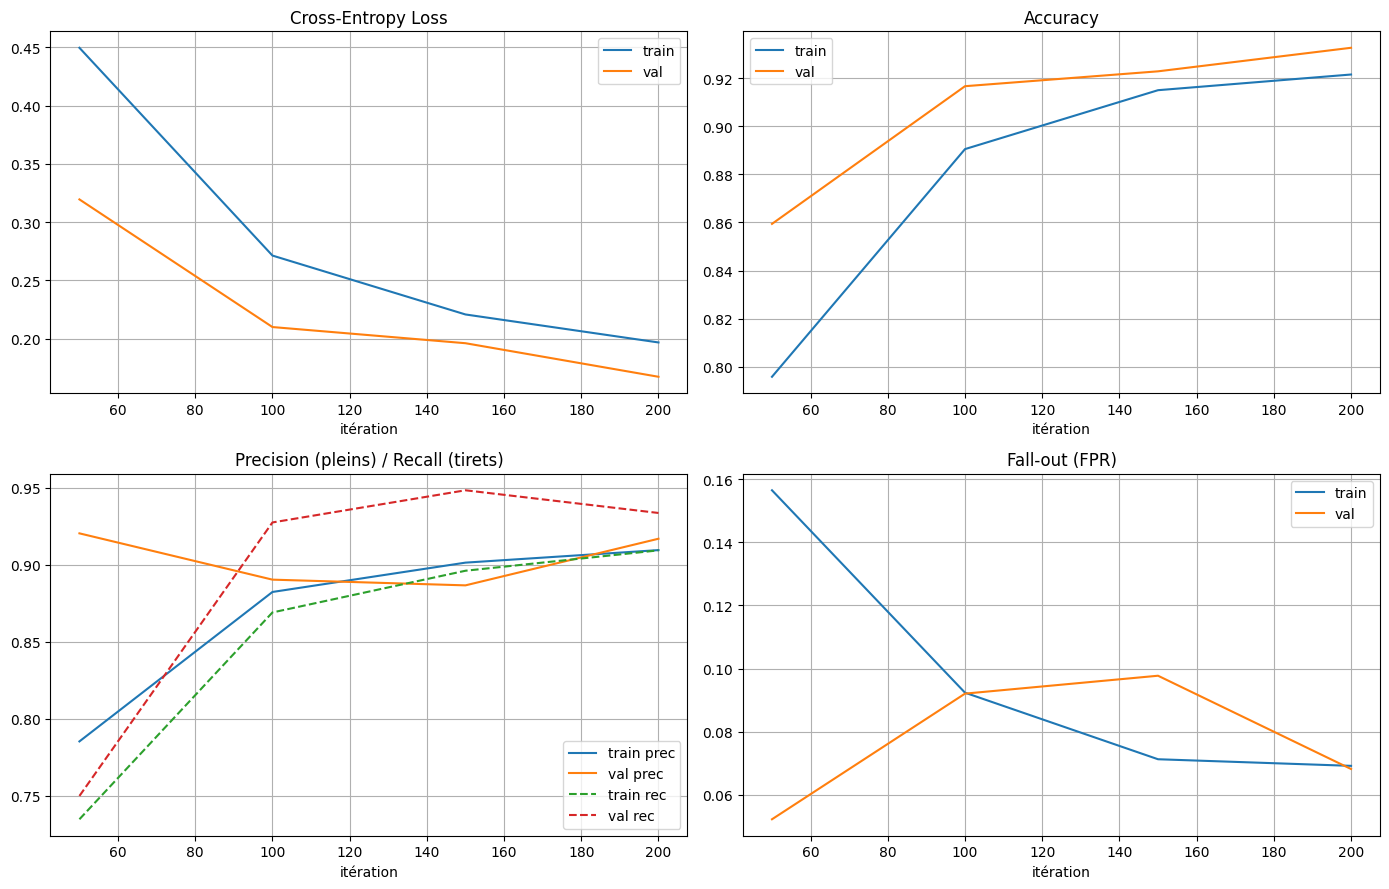

In [27]:
# Test rapide : 1 fold, 200 itérations (~10 min sur GPU T4)
# Remplace n_iter=200 par n_iter=N_ITERATIONS pour un vrai entraînement

train_ds_aug   = PosidoniaDataset(LOCAL_PATH, split='training', augment=True)
train_ds_noaug = PosidoniaDataset(LOCAL_PATH, split='training', augment=False)

indices = np.arange(len(train_ds_aug))
train_idx, val_idx = next(
    KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED).split(indices)
)

train_subset = Subset(train_ds_aug,   train_idx.tolist())
val_subset   = Subset(train_ds_noaug, val_idx.tolist())

ckpt, history = train_one_fold(
    train_subset, val_subset,
    n_iter=200,          # <- mettre N_ITERATIONS pour l'entraînement complet
    lr=LEARNING_RATE,
    model_path='quick_test_v3.pth',
    val_every=50,
    verbose=True
)
plot_history(history, 'quick_test_curves_v3.png')

#### 13. Entraînement complet

Décommenter selon ce que l'on veut lancer :
- **Option A** : 8 cas de la Table 2 (long)
- **Option B** : config gagnante + sélection parmi 50 modèles (section IV-B.2)

In [ ]:
# ── OPTION A : 8 configurations Table 2 ────────────────────────────────
# all_results = run_paper_study_cases()
# plot_roc(all_results)

# ── OPTION B : config gagnante, 10 runs × 5 folds = 50 modèles ──────────
best_ckpt, all_fold_results = run_10_times_and_select_best(tag='1_1_16')

# ── Visualisation qualitative sur le meilleur modèle ────────────────────
# model_final = FCN8VGG16(num_classes=N_CLASSES, pretrained=False).to(DEVICE)
# model_final.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
# show_qualitative(model_final, extra_ds, threshold=0.5, n=4)


########## RUN 1/10 ##########
Dataset [training] : 376 paires image/masque chargées
Dataset [training] : 376 paires image/masque chargées
Dataset [testing] : 94 paires image/masque chargées

========== Run 1 | Fold 1/5 ==========


Iterations:   3%|▎         | 500/16000 [2:04:00<62:07:08, 14.43s/it]

[iter    500] loss tr=0.2011 val=0.1251 *  |  acc tr=0.916 val=0.950  |  prec tr=0.912 val=0.935  |  rec tr=0.893 val=0.954  |  fall tr=0.066 val=0.054


Iterations:   6%|▋         | 1000/16000 [4:08:45<61:28:44, 14.75s/it]

[iter   1000] loss tr=0.0983 val=0.1109 *  |  acc tr=0.960 val=0.956  |  prec tr=0.953 val=0.931  |  rec tr=0.956 val=0.973  |  fall tr=0.036 val=0.058


...

Iterations:  81%|████████▏ | 13000/16000 [65:29:40<12:47:25, 15.35s/it]

[iter  13000] loss tr=0.0277 val=0.1362  |  acc tr=0.988 val=0.961  |  prec tr=0.986 val=0.954  |  rec tr=0.987 val=0.963  |  fall tr=0.011 val=0.040


Iterations:  84%|████████▍ | 13500/16000 [67:37:03<10:18:11, 14.84s/it]

[iter  13500] loss tr=0.0268 val=0.1386  |  acc tr=0.989 val=0.962  |  prec tr=0.986 val=0.954  |  rec tr=0.988 val=0.965  |  fall tr=0.010 val=0.040


Iterations:  85%|████████▌ | 13660/16000 [68:18:00<12:10:05, 18.72s/it]

In [ ]:
def save_fcn_reference(tag='1_1_16'):
    """
    Scanne KFOLD_DIR, agrège les métriques de tous les modèles de la config `tag`
    (jusqu'à N_RUNS x K_FOLDS = 50), et sauvegarde fcn_vgg16_reference.json
    dans RESULTS_DIR - analogue à segformer_{variant}_reference.json.
    """
    metas = []
    for fname in sorted(os.listdir(KFOLD_DIR)):
        if fname.startswith(f'fcn8_{tag}_run') and fname.endswith('_metadata.json'):
            with open(os.path.join(KFOLD_DIR, fname), 'r') as f:
                metas.append(json.load(f))

    if not metas:
        print(f'Aucune métadonnée trouvée pour tag={tag} dans {KFOLD_DIR}')
        return None

    precisions = [m['mix_metrics']['precision'] for m in metas]
    accuracies = [m['mix_metrics']['accuracy']  for m in metas]
    recalls    = [m['mix_metrics']['recall']    for m in metas]
    fallouts   = [m['mix_metrics']['fallout']   for m in metas]
    aucs_mix   = [m['mix_auc']                  for m in metas]

    precisions_extra = [m['extra_metrics']['precision'] for m in metas]
    accuracies_extra = [m['extra_metrics']['accuracy']  for m in metas]
    aucs_extra       = [m['extra_auc']                  for m in metas]

    # Sélection du meilleur modèle (score = (precision + accuracy)/2 sur le mix set)
    scores   = [(p + a) / 2 for p, a in zip(precisions, accuracies)]
    best_idx = int(np.argmax(scores))
    best     = metas[best_idx]

    reference = {
        'architecture': 'FCN8-VGG16 (Martin-Abadal 2018)',
        'tag': tag,
        'n_models': len(metas),
        'n_iterations': metas[0]['n_iter'],
        'learning_rate': metas[0]['lr'],
        'augment': metas[0]['augment'],
        'mix_set': {
            'precision': {'mean': float(np.mean(precisions)), 'std': float(np.std(precisions))},
            'accuracy':  {'mean': float(np.mean(accuracies)), 'std': float(np.std(accuracies))},
            'recall':    {'mean': float(np.mean(recalls)),    'std': float(np.std(recalls))},
            'fallout':   {'mean': float(np.mean(fallouts)),   'std': float(np.std(fallouts))},
            'auc':       {'mean': float(np.mean(aucs_mix)),   'std': float(np.std(aucs_mix))},
        },
        'extra_set': {
            'precision': {'mean': float(np.mean(precisions_extra)), 'std': float(np.std(precisions_extra))},
            'accuracy':  {'mean': float(np.mean(accuracies_extra)), 'std': float(np.std(accuracies_extra))},
            'auc':       {'mean': float(np.mean(aucs_extra)),       'std': float(np.std(aucs_extra))},
        },
        'best_model': {
            'name': best['name'],
            'ckpt_path': best['ckpt_path'],
            'mix_metrics': best['mix_metrics'],
            'mix_auc': best['mix_auc'],
            'extra_metrics': best['extra_metrics'],
            'extra_auc': best['extra_auc'],
        },
        # Valeurs de référence de l'article, pour comparaison directe dans le mémoire
        'article_reference': {
            'mix_precision': {'mean': 0.9695, 'std': 0.0097},
            'mix_accuracy':  {'mean': 0.9608, 'std': 0.0049},
            'best_model':    {'precision': 0.9657, 'accuracy': 0.9681},
        },
    }

    ref_path = os.path.join(RESULTS_DIR, 'fcn_vgg16_reference.json')
    with open(ref_path, 'w') as f:
        json.dump(reference, f, indent=2)

    print(f' Référence FCN8-VGG16 sauvegardée : {ref_path}')
    print(f'\n  {len(metas)} modèles agrégés (tag={tag})')
    print(f'  Mix   -> prec={reference["mix_set"]["precision"]["mean"]*100:.2f}%'
          f'±{reference["mix_set"]["precision"]["std"]*100:.2f}%  '
          f'acc={reference["mix_set"]["accuracy"]["mean"]*100:.2f}%'
          f'±{reference["mix_set"]["accuracy"]["std"]*100:.2f}%')
    print(f'  Meilleur modèle : {best["name"]}  '
          f'prec={best["mix_metrics"]["precision"]*100:.2f}%  '
          f'acc={best["mix_metrics"]["accuracy"]*100:.2f}%')
    print(f'  (Article : prec={reference["article_reference"]["mix_precision"]["mean"]*100:.2f}%'
          f'±{reference["article_reference"]["mix_precision"]["std"]*100:.2f}%  '
          f'acc={reference["article_reference"]["mix_accuracy"]["mean"]*100:.2f}%'
          f'±{reference["article_reference"]["mix_accuracy"]["std"]*100:.2f}%)')

    return reference


# Appel après run_10_times_and_select_best()
# fcn_reference = save_fcn_reference(tag='1_1_16')